In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from category_encoders import TargetEncoder

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
Churn_client= pd.read_csv("Dataset_churn.csv")
Churn_client

,msisdn,tenure_mths_cnt,gadget_type,device_category,smart_phone_flag,manufacturer,active_days_count_mth2,active_days_count_mth3,active_days_count_mth4,data_active_days_count_mth2,...,avg_paid_data_usage,avg_voice_usage,avg_voice_onnet_usage,avg_voice_offnet_usage,avg_recharge_tot_amount,max_recharge_tot_amount,active_days_count_diff_mth2_3,active_days_count_diff_mth3_4,avg_active_days_diff,value_segment
0,028D60F7F40E18BC63C43883B6B6EFD7,0.000000,unknown,Unknown,Unknown,unknown,0.000000,0.131148,0.032258,0.000000,...,3.392080e-04,0.001130,0.001445,0.000000,0.000170,0.000411,0.733333,0.406593,0.483871,Medium
1,4AB05A575719E7BFC3DD30968D608367,0.405738,mobile handset,2G,No,itel,0.129032,0.180328,0.032258,0.096774,...,0.000000e+00,0.000970,0.001241,0.000000,0.000158,0.000316,0.766667,0.439560,0.548387,Low
2,47366A6051322F08A46B327FBBAD03AC,0.086066,mobile handset,2G,No,itel,0.032258,0.081967,0.129032,0.032258,...,0.000000e+00,0.000749,0.000745,0.000503,0.000035,0.000047,0.866667,0.340659,0.451613,Low
3,B7221E307F39F210781D6E9529B213D1,0.057377,unknown,Unknown,Unknown,unknown,0.000000,0.049180,0.129032,0.032258,...,6.340000e-07,0.000004,0.000001,0.000009,0.000000,0.000000,0.900000,0.318681,0.435484,Low
4,A6086B2E16BF1630AD75AEA6D21714C2,0.040984,mobile handset,2G,No,tecno,0.774194,0.721311,0.032258,0.032258,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.802198,0.870968,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91359,654DEFDC7578BA01E387D0E6DDE54B34,0.221311,mobile handset,2G,No,itel,0.580645,0.655738,0.806452,0.000000,...,0.000000e+00,0.000539,0.000690,0.000000,0.000111,0.000126,0.266667,0.494505,0.387097,Low
91360,B71BCFA51DF724AF26608EBEA73F478C,0.131148,mobile handset,2G,No,other,0.096774,0.131148,0.258065,0.000000,...,0.000000e+00,0.002026,0.002060,0.001257,0.000192,0.000237,0.833333,0.329670,0.419355,Low
91361,F11DF3E6E69D487A8787701F56AC0CC4,0.004098,mobile handset,Non-Data,No,itel,0.870968,0.655738,0.451613,0.032258,...,0.000000e+00,0.002060,0.002635,0.000000,0.000697,0.001170,0.566667,0.615385,0.709677,Low
91362,DDABC68BFDFB39F967ECE77F7BA291AD,0.024590,mobile handset,Non-Data,No,samsung,0.129032,0.229508,0.193548,0.000000,...,0.000000e+00,0.000822,0.000051,0.002364,0.000216,0.000364,0.666667,0.417582,0.467742,Low


✓ Les valeurs 'unknown' ont été remplacées par NaN
✓ Colonnes avec annotations scientifiques : ['data_usage_tot_rev_mth2', 'data_usage_tot_rev_mth3', 'data_usage_tot_rev_mth4', 'paid_data_usage_mth2', 'paid_data_usage_mth3', 'paid_data_usage_mth4', 'total_data_usage_mth2', 'total_data_usage_mth3', 'total_data_usage_mth4', 'recharge_tot_amount_mth2', 'recharge_tot_amount_mth3', 'recharge_tot_amount_mth4', 'voice_outgoing_tot_rev_mth2', 'voice_outgoing_tot_rev_mth3', 'voice_outgoing_tot_rev_mth4', 'voice_outgoing_tot_duration_mth2', 'voice_outgoing_tot_duration_mth3', 'voice_outgoing_tot_duration_mth4', 'voice_outgoing_onnet_duration_mth2', 'voice_outgoing_onnet_duration_mth3', 'voice_outgoing_onnet_duration_mth4', 'voice_outgoing_offnet_duration_mth2', 'voice_outgoing_offnet_duration_mth3', 'voice_outgoing_offnet_duration_mth4', 'total_revenue_mth2', 'total_revenue_mth3', 'total_revenue_mth4', 'avg_data_usage', 'avg_paid_data_usage', 'avg_voice_usage', 'avg_voice_onnet_usage', 'avg_voic

C:\Users\HOBEN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✓ Entraînement terminé

Résultats :
Accuracy  : 0.9559
Precision : 0.5979
Recall    : 0.9678
F1-Score  : 0.7392
ROC-AUC   : 0.9897

Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     17093
           1       0.60      0.97      0.74      1180

    accuracy                           0.96     18273
   macro avg       0.80      0.96      0.86     18273
weighted avg       0.97      0.96      0.96     18273

Matrice de confusion :
[[16325   768]
 [   38  1142]]


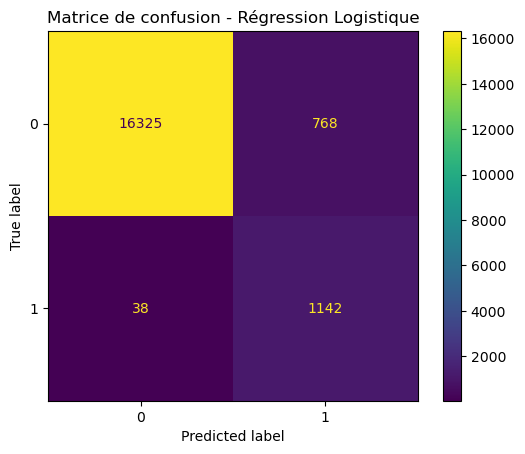



             RANDOM FOREST
✓ Entraînement terminé

Résultats :
Accuracy  : 0.9862
Precision : 0.8509
Recall    : 0.9525
F1-Score  : 0.8988
ROC-AUC   : 0.9982

Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     17093
           1       0.85      0.95      0.90      1180

    accuracy                           0.99     18273
   macro avg       0.92      0.97      0.95     18273
weighted avg       0.99      0.99      0.99     18273

Matrice de confusion :
[[16896   197]
 [   56  1124]]


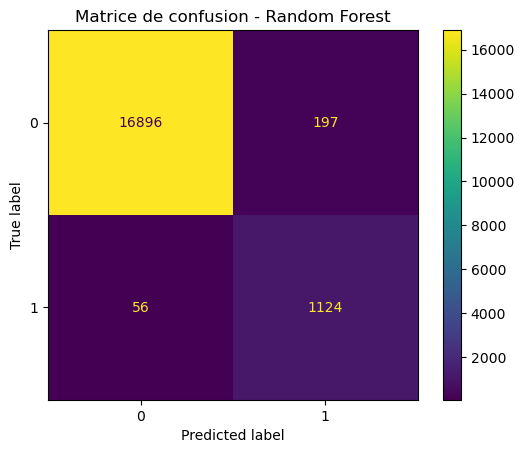



             XGBOOST
✓ Entraînement terminé

Résultats :
Accuracy  : 0.9958
Precision : 0.9458
Recall    : 0.9915
F1-Score  : 0.9681
ROC-AUC   : 0.9999

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17093
           1       0.95      0.99      0.97      1180

    accuracy                           1.00     18273
   macro avg       0.97      0.99      0.98     18273
weighted avg       1.00      1.00      1.00     18273

Matrice de confusion :
[[17026    67]
 [   10  1170]]


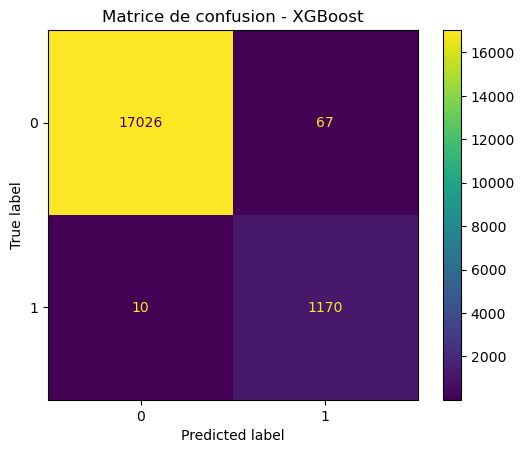



                 COMPARAISON DES 3 MODELES
               Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Régression Logistique  0.955891   0.597906 0.967797  0.739159 0.989657
        Random Forest  0.986154   0.850871 0.952542  0.898840 0.998217
              XGBoost  0.995786   0.945837 0.991525  0.968142 0.999873


MODELES CLASSES SELON LE F1-SCORE
               Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC
              XGBoost  0.995786   0.945837 0.991525  0.968142 0.999873
        Random Forest  0.986154   0.850871 0.952542  0.898840 0.998217
Régression Logistique  0.955891   0.597906 0.967797  0.739159 0.989657


MODELES CLASSES SELON LE ROC-AUC
               Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC
              XGBoost  0.995786   0.945837 0.991525  0.968142 0.999873
        Random Forest  0.986154   0.850871 0.952542  0.898840 0.998217
Régression Logistique  0.955891   0.597906 0.967797  0.739159 0.989657


                 MEILLEUR MODE

In [ ]:
# ============================================================
# 0. IMPORTATIONS
# ============================================================



# ============================================================
# 1. COPIE DU DATAFRAME
# ============================================================

df = Churn_client.copy()


# ============================================================
# 2. REMPLACER "UNKNOWN" PAR NaN
# ============================================================

df_str = df.astype(str).apply(
    lambda x: x.str.lower()
)

masque_unknown = df_str.apply(
    lambda x: x.str.contains(
        "unknow",
        regex=False
    )
)

for col in df.columns:
    df.loc[
        masque_unknown[col],
        col
    ] = np.nan


print("✓ Les valeurs 'unknown' ont été remplacées par NaN")


# ============================================================
# 3. DETECTION DES ANNOTATIONS SCIENTIFIQUES
# ============================================================

pattern_scientifique = r'^[+-]?\d+(\.\d+)?[eE][+-]?\d+$'

masque_sci = df.astype(str).apply(
    lambda x: x.str.match(
        pattern_scientifique
    )
)

cols_sci = (
    masque_sci.sum()[
        masque_sci.sum() > 0
    ]
    .index
    .tolist()
)


# Conversion des colonnes scientifiques
# en numériques

for col in cols_sci:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


print(
    f"✓ Colonnes avec annotations scientifiques : {cols_sci}"
)


# ============================================================
# 4. CREATION DE LA VARIABLE CIBLE
# ============================================================

# Churn = 1 :
# aucun jour d'activité pendant mth2
#
# Actif = 0 :
# au moins un jour d'activité

df["churn"] = np.where(
    df["active_days_count_mth2"] == 0,
    1,
    0
)


print("\n✓ Variable churn créée")

print(
    f"Taux de churn : {df['churn'].mean():.2%}"
)

print("\nDistribution :")

print(
    df["churn"].value_counts()
)


# ============================================================
# 5. CREATION DE X ET y
# ============================================================

cols_to_drop = [
    "churn",
    "msisdn",
    "active_days_count_mth2"
]

cols_to_drop = [
    col
    for col in cols_to_drop
    if col in df.columns
]

X = df.drop(
    columns=cols_to_drop
)

y = df["churn"]


print("\n============================================================")
print("X ET y")
print("============================================================")

print(
    "Dimensions X :",
    X.shape
)

print(
    "Dimensions y :",
    y.shape
)


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n============================================================")
print("TRAIN / TEST SPLIT")
print("============================================================")

print(
    "X_train :",
    X_train.shape
)

print(
    "X_test  :",
    X_test.shape
)

print("\ny_train :")
print(
    y_train.value_counts()
)

print("\ny_test :")
print(
    y_test.value_counts()
)


# ============================================================
# 7. VARIABLES CATEGORIELLES
# ============================================================

cols_candidats = [
    "device_category",
    "manufacturer",
    "gadget_type",
    "smart_phone_flag",
    "value_segment"
]

cols_target_encode = [
    col
    for col in cols_candidats
    if col in X_train.columns
]


# ============================================================
# 8. VARIABLES NUMERIQUES
# ============================================================

cols_numeriques = [
    col
    for col in X_train.columns
    if col not in cols_target_encode
]


print("\n============================================================")
print("VARIABLES")
print("============================================================")

print(
    "Variables catégorielles :",
    cols_target_encode
)

print(
    "\nNombre de variables numériques :",
    len(cols_numeriques)
)


# ============================================================
# 9. PIPELINE NUMERIQUE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[

        # Imputation par médiane
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        # RobustScaler
        (
            "scaler",
            RobustScaler()
        )
    ]
)


# ============================================================
# 10. PIPELINE CATEGORIELLE
# ============================================================

categorical_pipeline = Pipeline(
    steps=[

        # Remplacer les NaN par le mode
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        # Target Encoding
        #
        # IMPORTANT :
        # ta version utilise "smoothing"
        # et non "smooth"

        (
            "target_encoder",
            TargetEncoder(
                smoothing=10
            )
        )
    ]
)


# ============================================================
# 11. PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            numeric_pipeline,
            cols_numeriques
        ),

        (
            "categorical",
            categorical_pipeline,
            cols_target_encode
        )
    ],

    remainder="drop"
)


# ============================================================
# 12. MODELES
# ============================================================

models = {

    "Régression Logistique":

        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),


    "Random Forest":

        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),


    "XGBoost":

        XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )
}


# ============================================================
# 13. STOCKAGE DES RESULTATS
# ============================================================

results = []

trained_pipelines = {}


# ============================================================
# 14. ENTRAINEMENT DES MODELES
# ============================================================

for name, model in models.items():

    print("\n")
    print("=" * 70)

    print(
        f"             {name.upper()}"
    )

    print("=" * 70)


    # --------------------------------------------------------
    # Création de la pipeline
    # --------------------------------------------------------

    pipeline = ImbPipeline(
        steps=[

            # 1. Prétraitement
            (
                "preprocessing",
                preprocessor
            ),

            # 2. SMOTE
            #
            # SMOTE est exécuté uniquement
            # sur les données d'entraînement

            (
                "smote",
                SMOTE(
                    random_state=42
                )
            ),

            # 3. Modèle
            (
                "model",
                model
            )
        ]
    )


    # --------------------------------------------------------
    # Entraînement
    # --------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train
    )


    print(
        "✓ Entraînement terminé"
    )


    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    y_pred = pipeline.predict(
        X_test
    )


    # Probabilité churn

    y_proba = pipeline.predict_proba(
        X_test
    )[:, 1]


    # --------------------------------------------------------
    # METRIQUES
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_proba
    )


    # --------------------------------------------------------
    # SAUVEGARDE
    # --------------------------------------------------------

    results.append({

        "Modèle": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-Score": f1,

        "ROC-AUC": roc_auc
    })


    # Sauvegarde de la pipeline

    trained_pipelines[name] = pipeline


    # --------------------------------------------------------
    # AFFICHAGE
    # --------------------------------------------------------

    print("\nRésultats :")

    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1-Score  : {f1:.4f}"
    )

    print(
        f"ROC-AUC   : {roc_auc:.4f}"
    )


    # --------------------------------------------------------
    # CLASSIFICATION REPORT
    # --------------------------------------------------------

    print(
        "\nClassification Report :"
    )

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


    # --------------------------------------------------------
    # MATRICE DE CONFUSION
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )


    print(
        "Matrice de confusion :"
    )

    print(cm)


    # --------------------------------------------------------
    # GRAPHIQUE
    # --------------------------------------------------------

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()

    plt.title(
        f"Matrice de confusion - {name}"
    )

    plt.show()


# ============================================================
# 15. TABLEAU COMPARATIF
# ============================================================

results_df = pd.DataFrame(
    results
)


print("\n")
print("=" * 70)

print(
    "                 COMPARAISON DES 3 MODELES"
)

print("=" * 70)


print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 16. CLASSEMENT F1-SCORE
# ============================================================

results_sorted_f1 = results_df.sort_values(
    by="F1-Score",
    ascending=False
)


print("\n")
print("=" * 70)

print(
    "MODELES CLASSES SELON LE F1-SCORE"
)

print("=" * 70)


print(
    results_sorted_f1.to_string(
        index=False
    )
)


# ============================================================
# 17. CLASSEMENT ROC-AUC
# ============================================================

results_sorted_auc = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)


print("\n")
print("=" * 70)

print(
    "MODELES CLASSES SELON LE ROC-AUC"
)

print("=" * 70)


print(
    results_sorted_auc.to_string(
        index=False
    )
)


# ============================================================
# 18. MEILLEUR MODELE
# ============================================================

best_model_name = (
    results_sorted_f1.iloc[0]["Modèle"]
)


best_pipeline = trained_pipelines[
    best_model_name
]


print("\n")
print("=" * 70)

print(
    "                 MEILLEUR MODELE"
)

print("=" * 70)


print(
    "Meilleur modèle selon le F1-Score :",
    best_model_name
)